In [5]:
%pip install gym

Note: you may need to restart the kernel to use updated packages.


Using own code since d2l package is broken

In [6]:
%matplotlib inline
import random
import gym
import numpy as np
from d2l import torch as d2l

seed = 0 # Random number generator seed
gamma = 0.95 # Discount factor
num_iters = 256 # Number of iterations
alpha = 0.9
epsilon = 0.9
random.seed(seed)
np.random.seed(seed)

# Create environment directly
env = gym.make('FrozenLake-v1', is_slippery=False, desc=None, map_name="4x4")
env.reset(seed=seed)  # Added seed for reproducibility
env.action_space.seed(seed)

# Create env_info with the correct structure
env_info = {
    'desc': env.desc if hasattr(env, 'desc') else None,
    'env': env,  # This is the key missing from your original code
    'num_states': env.observation_space.n,
    'num_actions': env.action_space.n,
}

In FrozenLake environment, the robot moves on a 4x4 grid (these are the states) with actions of up, down, left, and right. Environment contains some holes (H) and frozen (F) cells as well as a goal cell (G), all unknown to the robot.

For simplicity, we assume the robot has reliable actions ($P(s'|s,a)=1 \ \forall s \in S, a \in A$). If the robot reaches its goal, the trial ends and the robot receives a reward of 1 irrespective of the action; the reward at any other state is 0 for all actions.

The objective of the robot is to learn a policy that reaches the goal location (G) from a given start location S (this is $s_0$) to maximize the return.

In [7]:
def e_greedy(env, Q, s, epsilon):
    """e-greedy exploration algorithm for Q-Learning."""
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[s,:])

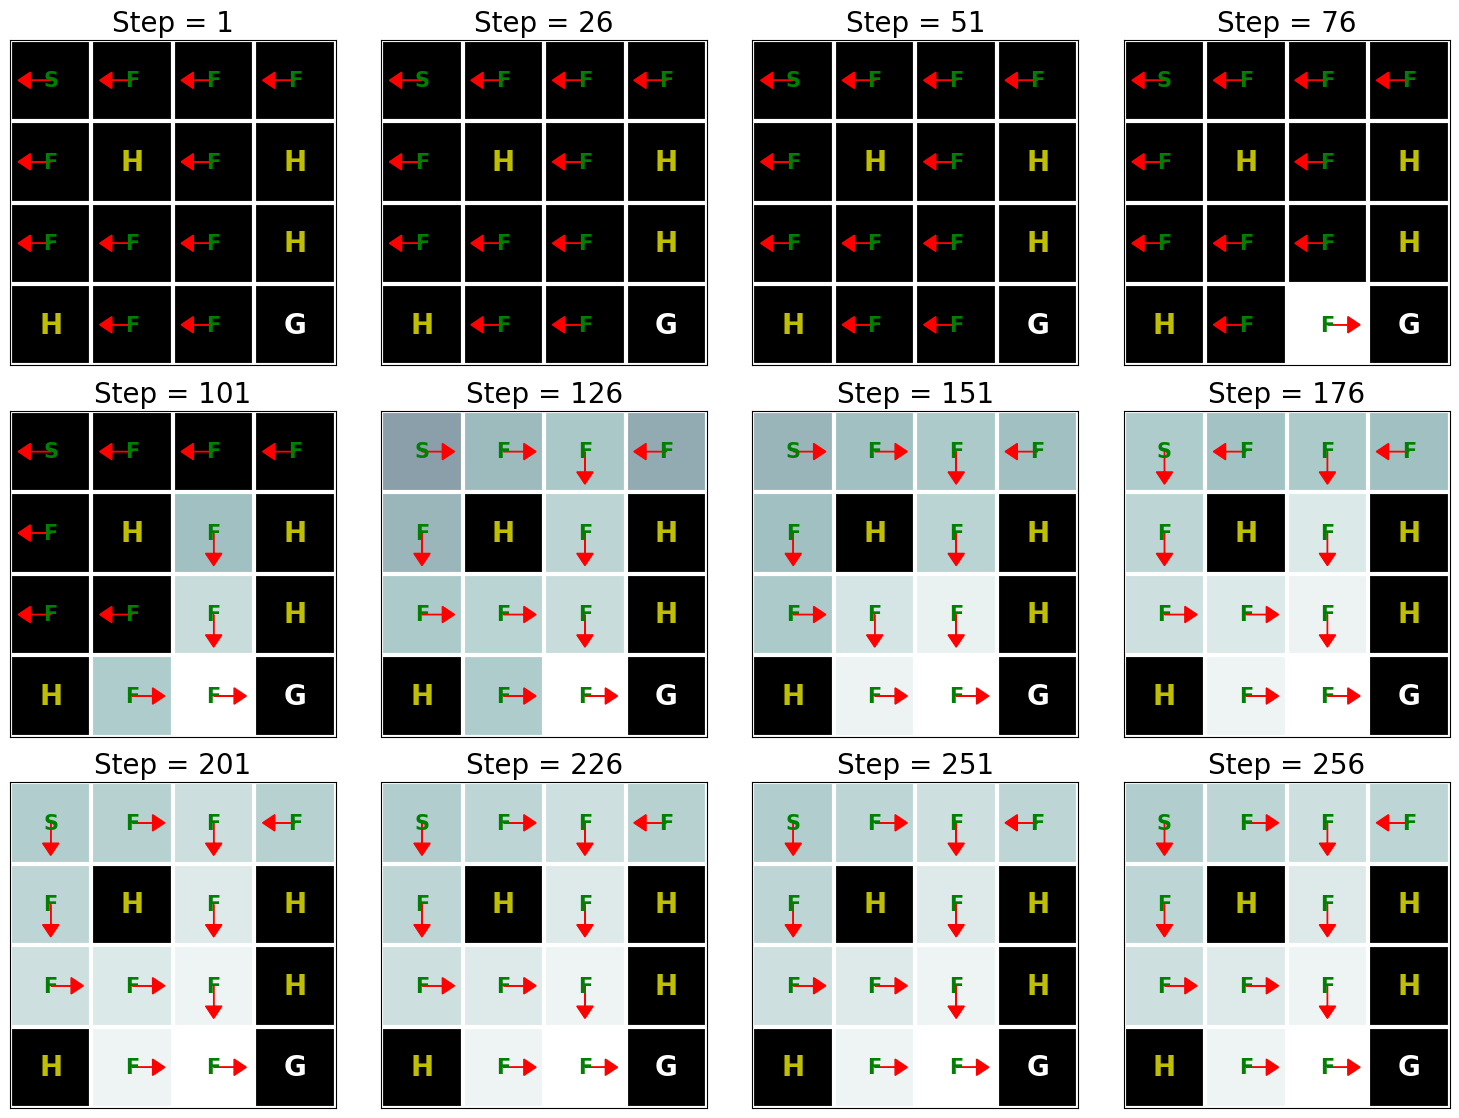

In [20]:
def q_learning(env_info, gamma, num_iters, alpha, epsilon):
    env_desc = env_info['desc'] # 2D array specifying what each grid item means
    env = env_info['env'] # 2D array specifying what each grid item means
    num_states = env_info['num_states']
    num_actions = env_info['num_actions']

    Q = np.zeros((num_states, num_actions))
    V = np.zeros((num_iters+1, num_states)) # value fn values at each state
    pi = np.zeros((num_iters + 1, num_states)) # policies

    for k in range(1, num_iters + 1):
        # Reset environment
        state, done = env.reset()[0], False
        while not done:
            # Select an action for a given state and acts in env based on selected action
            action = e_greedy(env, Q, state, epsilon)
            next_state, reward, done, _, _ = env.step(action)

            # Q-update:
            y = reward + gamma * np.max(Q[next_state,:])
            Q[state, action] = Q[state, action] + alpha * (y - Q[state, action])

            # Move to the next state
            state = next_state
        # Record max value and max action for visualization purposes only
        for s in range(num_states):
            V[k,s] = np.max(Q[s,:]) # Choose value corresponding to best action
            pi[k,s] = np.argmax(Q[s,:]) # Fill stochastic policy
    d2l.show_Q_function_progress(env_desc, V[:-1], pi[:-1])

q_learning(env_info=env_info, gamma=gamma, num_iters=num_iters, alpha=alpha, epsilon=epsilon)